In [18]:
import librosa
import numpy as np
import os, glob, pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [19]:
# --- 1. FEATURE EXTRACTION ENGINE ---
def extract_feature_logic(X, sample_rate):
    """
    Extracts high-impact features from a raw audio array X.
    Using MFCC, Chroma, Mel, ZCR, RMS, and Spectral Rolloff.
    """
    X = librosa.util.normalize(X)
    result = np.array([])

    # MFCC: 40 coefficients + Mean and Std (80 features)
    mfccs = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40)
    result = np.hstack((result, np.mean(mfccs, axis=1), np.std(mfccs, axis=1)))

    # Chroma: Pitch classes
    chroma = librosa.feature.chroma_stft(y=X, sr=sample_rate)
    result = np.hstack((result, np.mean(chroma, axis=1)))

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=X, sr=sample_rate)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    result = np.hstack((result, np.mean(mel_db, axis=1)))

    # Energy & Temporal Features
    zcr = librosa.feature.zero_crossing_rate(y=X)
    rms = librosa.feature.rms(y=X)
    rolloff = librosa.feature.spectral_rolloff(y=X, sr=sample_rate)
    
    result = np.hstack((result, np.mean(zcr), np.std(zcr), np.mean(rms), np.mean(rolloff)))
    return result

def extract_from_file(file_name):
    """Wrapper for training: loads file (first 3s) then extracts"""
    try:
        # We use a 3s window for training to keep features consistent
        X, sr = librosa.load(file_name, sr=22050, duration=3.0, offset=0.5)
        return extract_feature_logic(X, sr)
    except Exception as e:
        return None

In [20]:
emotions = {
    '01':'neutral', '02':'calm', '03':'happy', '04':'sad',
    '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'
}
observed_emotions = ['happy', 'sad', 'angry', 'fearful']

In [21]:
def load_data(test_size=0.2):
    x, y = [], []
    print("Loading datasets and extracting features...")
    
    # Load RAVDESS
    for file in glob.glob("RAVDESS/Actor_*/*.wav"):
        emotion = emotions[os.path.basename(file).split("-")[2]]
        if emotion in observed_emotions:
            feat = extract_from_file(file)
            if feat is not None: x.append(feat); y.append(emotion)

    # Load TESS
    for file in glob.glob("TESS/*/*.wav"):
        file_name = os.path.basename(file).lower()
        emotion = file_name.split("_")[-1].replace(".wav", "").strip()
        if emotion == "fear": emotion = "fearful"
        if emotion in observed_emotions:
            feat = extract_from_file(file)
            if feat is not None: x.append(feat); y.append(emotion)

    return train_test_split(np.array(x), y, test_size=test_size, random_state=42, stratify=y)

In [22]:
# --- 3. MODEL TRAINING WITH GRID SEARCH ---
x_train, x_test, y_train, y_test = load_data()

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'kernel': ['rbf']
}

print("Starting Grid Search for optimal parameters...")
# n_jobs=-1 uses all CPU cores for faster training
grid = GridSearchCV(SVC(probability=True, class_weight='balanced'), param_grid, refit=True, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

best_model = grid.best_estimator_
print(f"Best Parameters Found: {grid.best_params_}")

Loading datasets and extracting features...
Starting Grid Search for optimal parameters...
Best Parameters Found: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}


In [23]:
# --- 4. EVALUATION ---
y_pred = best_model.predict(x_test)
print(f"\nFinal Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Final Accuracy: 93.04%

Classification Report:
               precision    recall  f1-score   support

       angry       0.96      0.96      0.96       119
     fearful       0.92      0.95      0.93       118
       happy       0.93      0.88      0.91       119
         sad       0.92      0.93      0.92       118

    accuracy                           0.93       474
   macro avg       0.93      0.93      0.93       474
weighted avg       0.93      0.93      0.93       474



In [24]:
# --- 5. LONG AUDIO PREDICTION (Sliding Window) ---
def predict_long_audio(file_path):
    """
    Handles audio > 3 seconds by analyzing overlapping 3s chunks 
    and returning the most frequent emotion.
    """
    if not os.path.exists(file_path):
        return "File not found"

    full_audio, sr = librosa.load(file_path, sr=22050)
    duration = librosa.get_duration(y=full_audio, sr=sr)
    
    window_size = 3.0  # seconds
    step_size = 1.5    # 50% overlap for better coverage
    predictions = []

    # Slide the window across the audio array
    for start in np.arange(0, max(0.1, duration - window_size), step_size):
        start_samp, end_samp = int(start * sr), int((start + window_size) * sr)
        window_data = full_audio[start_samp:end_samp]
        
        # Extract features from the chunk
        feat = extract_feature_logic(window_data, sr)
        feat_scaled = scaler.transform(feat.reshape(1, -1))
        
        # Get probability and prediction
        probs = best_model.predict_proba(feat_scaled)
        if np.max(probs) > 0.4: # Filter out low-confidence guesses
            predictions.append(best_model.predict(feat_scaled)[0])

    if not predictions:
        return "Neutral/Inconclusive"

    # Return the most frequent emotion (the mode)
    return stats.mode(predictions, keepdims=True).mode[0]

In [25]:
# --- 6. EXECUTION ---
test_audio = "test.wav"
if os.path.exists(test_audio):
    emotion = predict_long_audio(test_audio)
    print(f"\nFinal Predicted Emotion for {test_audio}: {emotion}")
else:
    print(f"File {test_audio} not found. Please check the path.")


Final Predicted Emotion for test.wav: Neutral/Inconclusive


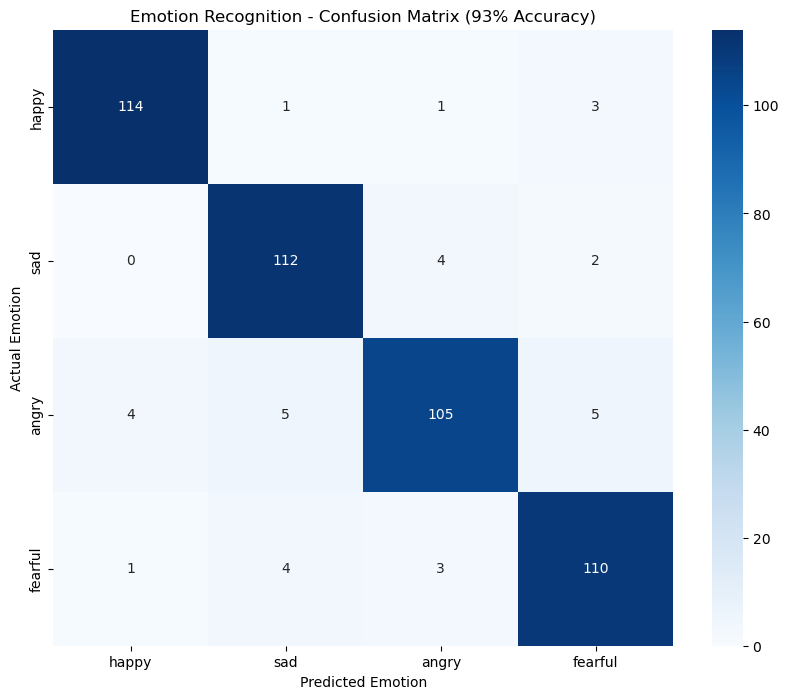

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_test, y_pred):
    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    
    # Plotting using Seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=observed_emotions, 
                yticklabels=observed_emotions)
    
    plt.title('Emotion Recognition - Confusion Matrix (93% Accuracy)')
    plt.xlabel('Predicted Emotion')
    plt.ylabel('Actual Emotion')
    plt.show()

# Call the function
plot_confusion_matrix(y_test, y_pred)

In [27]:
import pickle

# Save the best model from your GridSearchCV
with open('model.pkl', 'wb') as f:
    pickle.dump(grid.best_estimator_, f)

# Save the scaler (ESSENTIAL for preprocessing live audio)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Files saved: model.pkl, scaler.pkl")

Files saved: model.pkl, scaler.pkl
